In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm

# reload utils
import importlib
importlib.reload(utils)


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 7 #Length of sequences

windowSizes = [1, 2, 3, 7]

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

# total_sub_num = 10
sub_nums = [1,2,3, 4, 5, 6, 7, 8, 9, 10]

num_trained_seq = 1

total_sub_num = 20
num_sessions = 3
num_blocks_per_session = 4

num_baseline_blocks = 1
num_trials_per_block = 40

percentile_low = 45;	# Lower percentile for ETs
percentile_high = 80;	# Upper percentile for ETs
percentile_low_super = 10;	# Lower percentile for ETs



In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [3]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

In [4]:
subjs

,BN,TN,SubNum,hand,isTrain,cue,press1,press2,press3,press4,...,useMetronome,isCross,crossTime,globalStartTime,IPI1,IPI2,IPI3,IPI4,IPI5,IPI6
0,1,1,1,2,0,1243514,1,2,4,3,...,0,0,0,Tue Jun 03 18:11:57 2025,200,330,430,595,235,450
1,1,2,1,2,0,1532324,1,5,3,2,...,0,0,0,Tue Jun 03 18:12:04 2025,340,645,330,600,330,360
2,1,3,1,2,0,5142423,5,1,4,2,...,0,0,0,Tue Jun 03 18:12:10 2025,240,405,455,820,250,1290
3,1,4,1,2,0,5253431,5,2,5,3,...,0,0,0,Tue Jun 03 18:12:18 2025,365,495,665,395,445,310
4,1,5,1,2,0,4342531,4,3,4,2,...,0,0,0,Tue Jun 03 18:12:25 2025,260,235,655,315,1000,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6795,17,36,10,2,1,3512434,3,5,1,2,...,0,0,0,Fri Jun 27 18:57:39 2025,275,375,190,485,360,205
6796,17,37,10,2,1,3512434,3,5,1,2,...,0,1,5,Fri Jun 27 18:57:44 2025,0,0,0,0,0,0
6797,17,38,10,2,1,3512434,3,5,1,2,...,0,0,0,Fri Jun 27 18:57:47 2025,290,345,215,495,335,215
6798,17,39,10,2,1,3512434,3,5,1,2,...,0,0,0,Fri Jun 27 18:57:53 2025,345,555,615,375,265,235


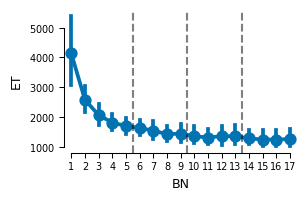

In [207]:
subjs_correct = utils.remove_error_trials(subjs) ###Removing error trials
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN']).agg({
    'ET': 'median'
}).reset_index()
sns.pointplot(data = subjs_grouped, x = 'BN', y = 'ET')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)


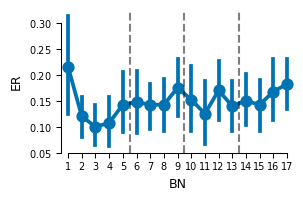

In [214]:
error_data = subjs.copy()
error_data['count'] = 1
error_data = error_data.groupby(['SubNum', 'BN']).agg({
    'count': 'sum',
    'isError': 'sum'
}).reset_index()

error_data['ER'] = error_data['isError'] / error_data['count']


sns.pointplot(data = error_data, x = 'BN', y = 'ER')
for day_change in [4.5, 8.5, 12.5]:
    plt.axvline(day_change, color = 'k', linestyle = '--', alpha = 0.5)
sns.despine(trim = True)

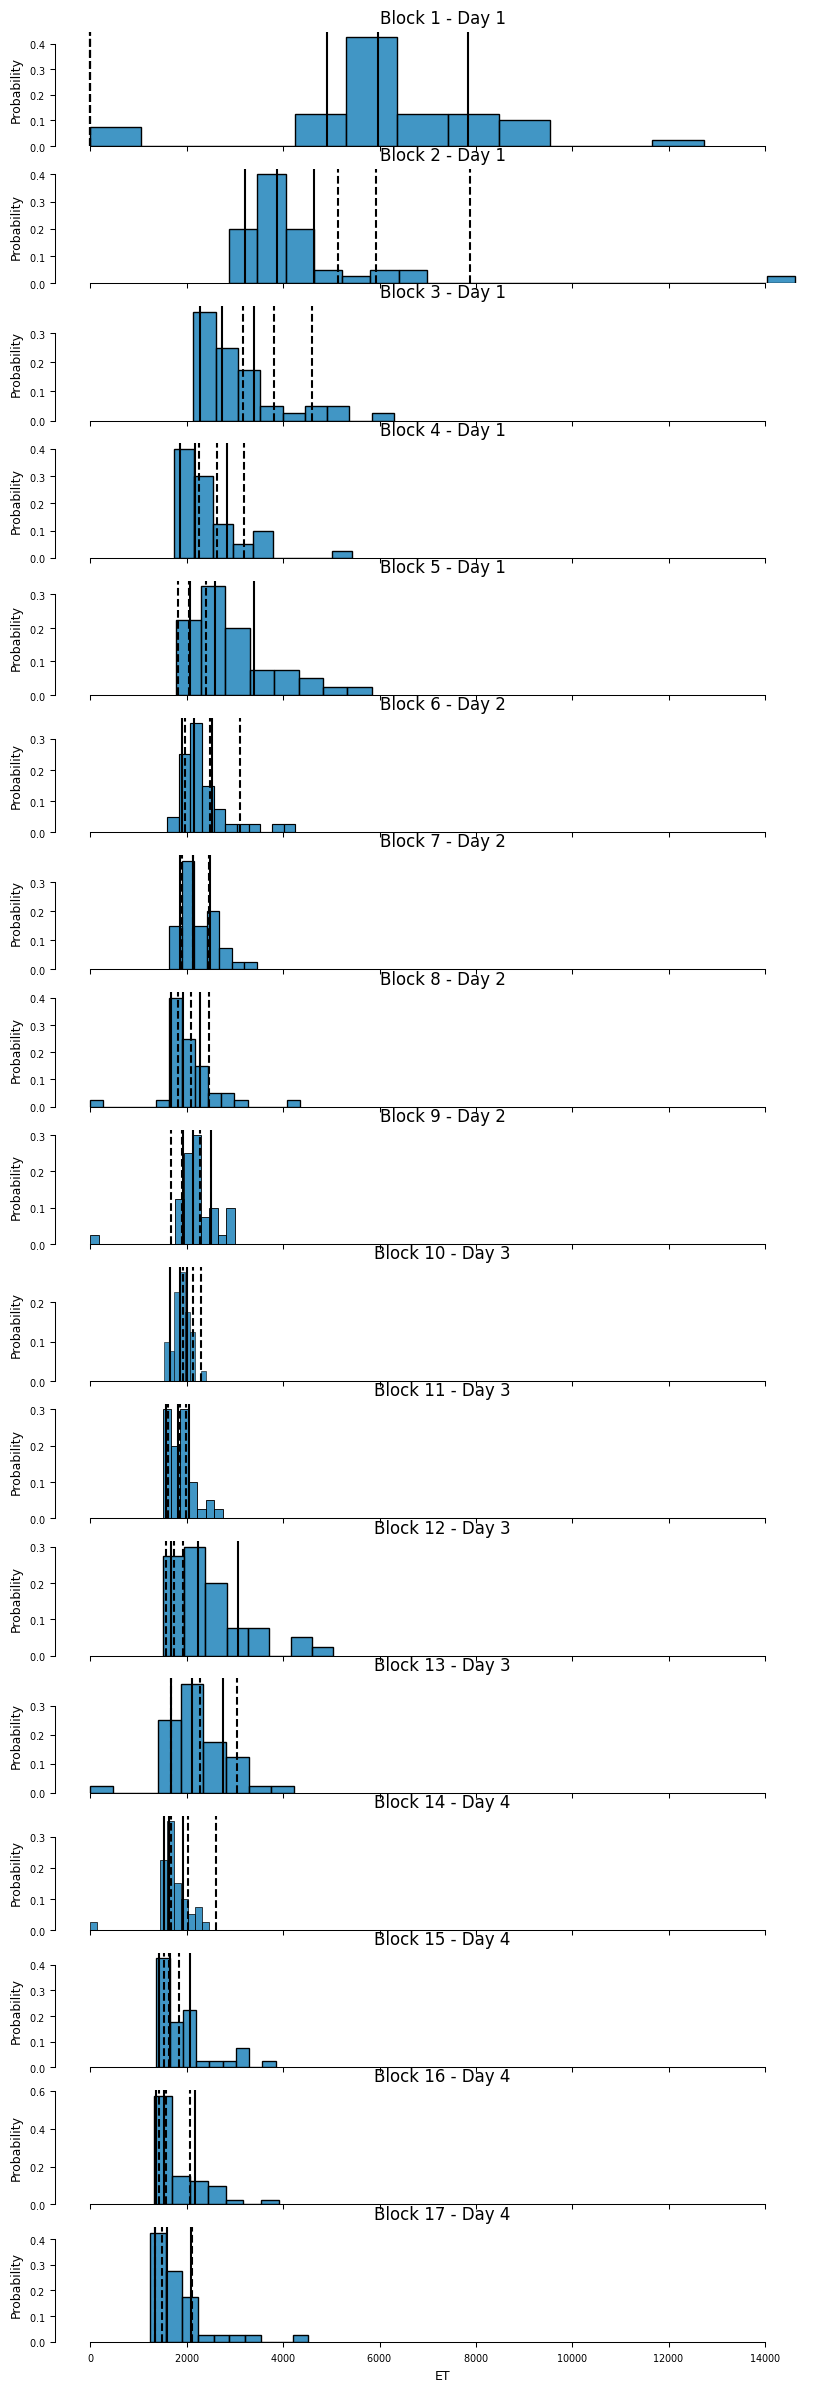

In [136]:
fig, axs = plt.subplots(len(subjs['BN'].unique()),1, figsize=(10, 30), sharex=True)
selected_sub = subjs[subjs['SubNum'] == 6] ###Selecting one subject
day_changes = [5.5, 9.5, 13.5, 17.5] #Day change points

# selected_sub = utils.remove_error_trials(selected_sub) ###Removing error trials for the selected subject
for bn, block_data in selected_sub.groupby('BN'):
    sns.histplot(data = block_data, x = 'ET', ax = axs[bn-1], stat = 'probability')
    axs[bn-1].axvline(block_data['estimatedPercentileHigh'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLow'].values[0], linestyle = '--', color = 'black')
    axs[bn-1].axvline(block_data['estimatedPercentileLowSuper'].values[0],linestyle = '--', color = 'black')

    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low_super), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_low), linestyle = '-', color = 'black')
    axs[bn-1].axvline(np.percentile(block_data['ET'], percentile_high), linestyle = '-', color = 'black')


    
    for day, day_change in enumerate(day_changes):
        if bn < day_change:
            break


    

    axs[bn-1].set_title(f'Block {bn} - Day {day+1}')

sns.despine(trim = True)

# Force Analysis

In [5]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

In [6]:
# exclude first block 
subjs = subjs[subjs['BN'] > 1]
rank_df = pd.DataFrame(index = subjs.index)
for subnum, data in subjs.groupby('SubNum'):
    data = data.sort_values(by = ['BN', 'TN'])
    data['N'] = data.groupby(['BN', 'TN']).ngroup() + 1
    rank_df.loc[data.index, 'N'] = data['N'].astype('int')
        

subjs['N'] = rank_df['N'].astype('int')
subjs = subjs[subjs['isCross'] == 0]

# adding day column to subjs
day1_blocks =list(range(2, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17


In [7]:
subjs.columns

Index(['BN', 'TN', 'SubNum', 'hand', 'isTrain', 'cue', 'press1', 'press2',
       'press3', 'press4', 'press5', 'press6', 'press7', 'RT', 'ET', 'MT',
       'isError', 'timingError', 'points', 'zone', 'response1', 'response2',
       'response3', 'response4', 'response5', 'response6', 'response7',
       'handPressed1', 'handPressed2', 'handPressed3', 'handPressed4',
       'handPressed5', 'handPressed6', 'handPressed7', 'pressTime1',
       'pressTime2', 'pressTime3', 'pressTime4', 'pressTime5', 'pressTime6',
       'pressTime7', 'timeThreshold', 'timeThresholdSuper',
       'estimatedPercentileHigh', 'estimatedPercentileLow',
       'estimatedPercentileLowSuper', 'startTime', 'startTimeReal', 'trialDur',
       'startTR', 'startTRtime', 'useMetronome', 'isCross', 'crossTime',
       'globalStartTime', 'IPI1', 'IPI2', 'IPI3', 'IPI4', 'IPI5', 'IPI6', 'N'],
      dtype='object')

In [8]:
aligned_cut_force = pd.read_csv(utils.path_misc+'aligned_cut_force.csv', sep = '\t')

In [9]:
aligned_cut_force = aligned_cut_force[aligned_cut_force['isCross'] == 0]

In [142]:
aligned_cut_force

,state,time,BN,TN,SubNum,isTrain,isCross,crossTime,points,zone,isError,RT,ET,Force_Number,Force_Value,N
0,3.0,-0.100334,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.143511,1
1,3.0,-0.096990,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.157839,1
2,3.0,-0.093645,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.172883,1
3,3.0,-0.090301,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.185659,1
4,3.0,-0.086957,2,1,1,1,0,0,3,2,0,865,3025,force1R,0.197230,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11518345,4.0,1.086957,17,40,10,1,0,0,1,2,0,460,2220,force5R,0.070896,640
11518346,4.0,1.090301,17,40,10,1,0,0,1,2,0,460,2220,force5R,0.067264,640
11518347,4.0,1.093645,17,40,10,1,0,0,1,2,0,460,2220,force5R,0.059200,640
11518348,4.0,1.096990,17,40,10,1,0,0,1,2,0,460,2220,force5R,0.060200,640


### plot original forces at different trials

In [10]:
subjs_forces = pd.read_csv(utils.path_misc+'subjs_force_train.csv', sep = '\t')

In [144]:
def plot_force_original(subnum, n):
    """
    Plot the force data for a given subject and trial number.
    
    Parameters:
        subnum (int): Subject number.
        n (int): Trial number.
    """
    sub_data = subjs_forces[(subjs_forces['SubNum'] == subnum) & (subjs_forces['N'] == n)]
    
    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and N {n}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, Trial {n}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.show()

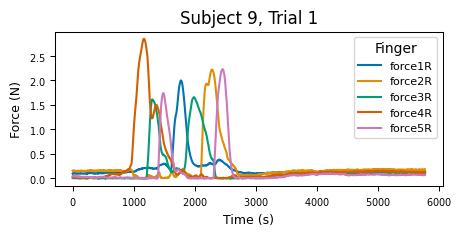

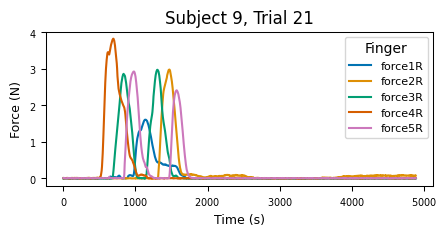

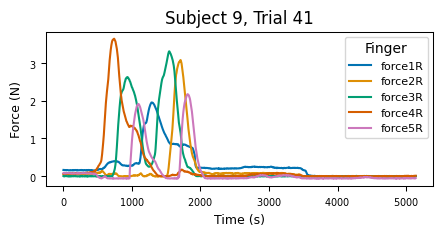

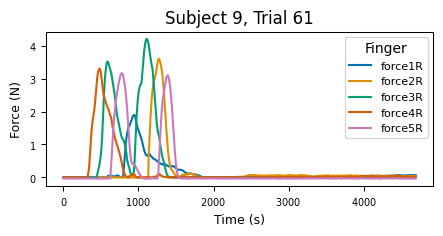

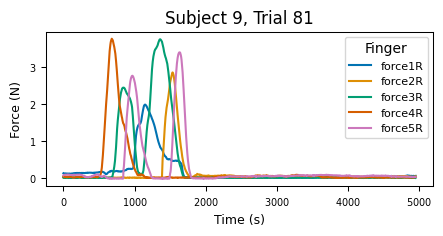

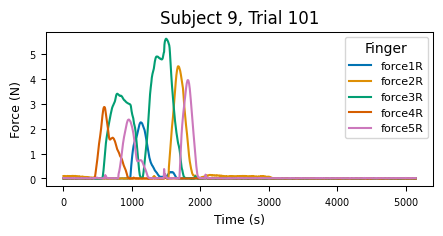

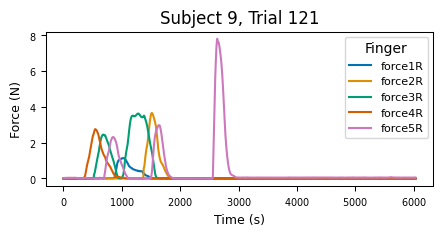

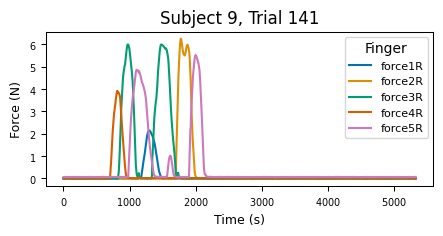

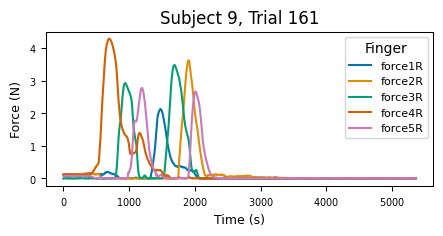

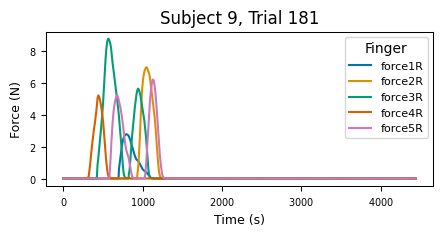

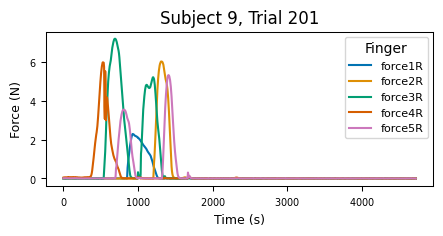

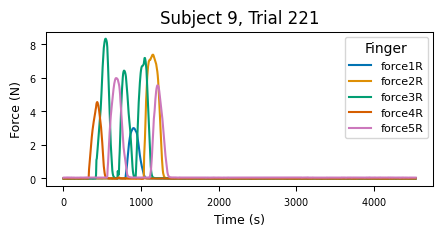

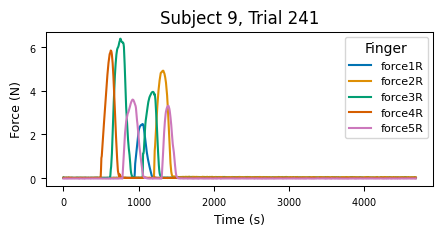

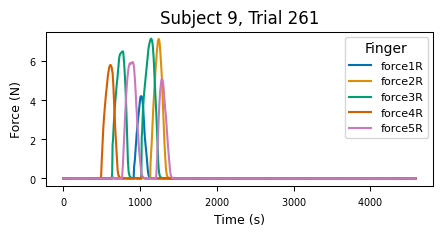

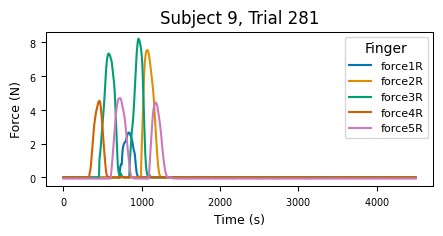

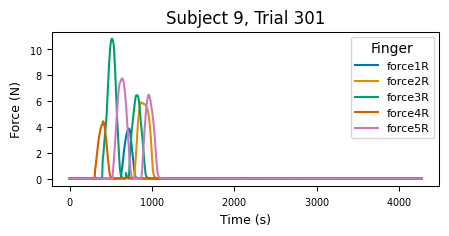

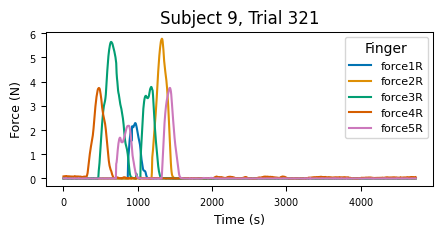

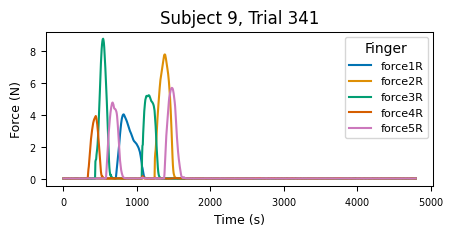

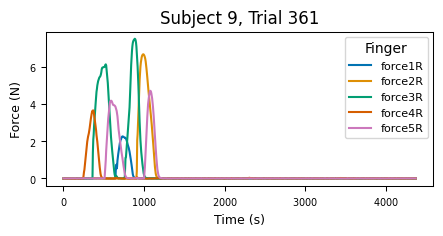

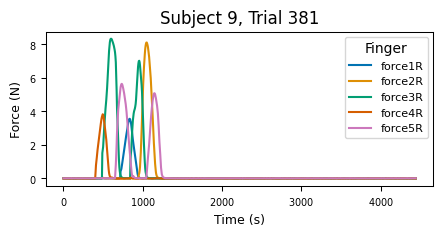

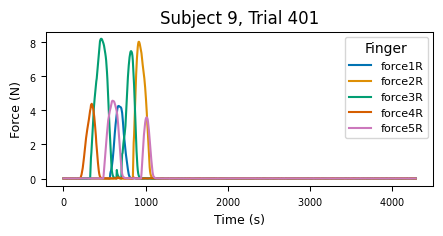

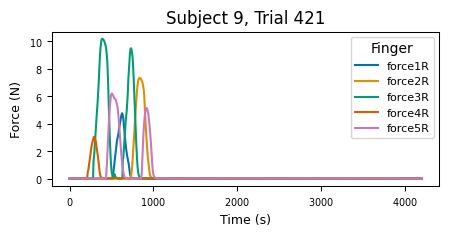

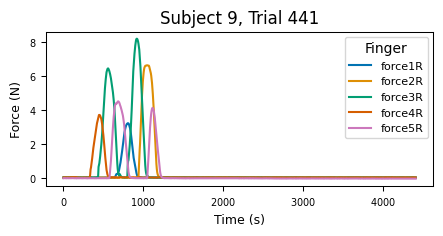

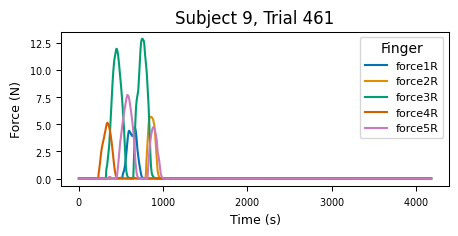

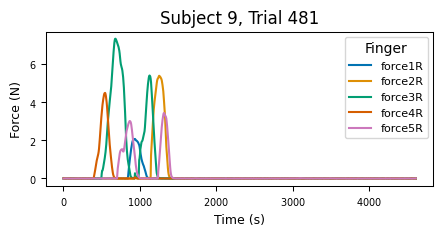

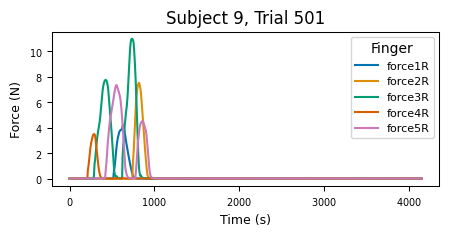

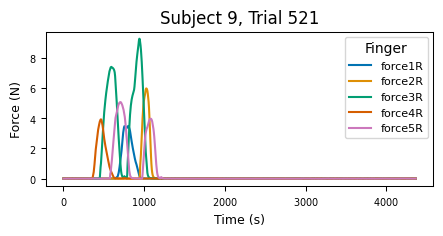

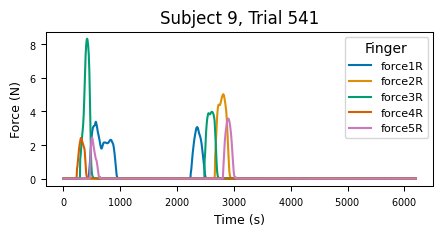

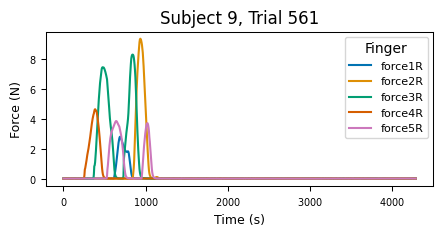

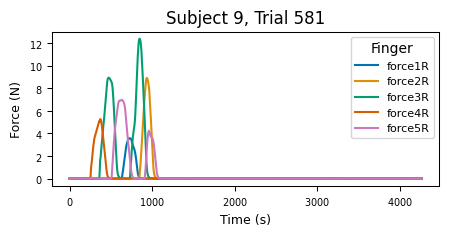

In [263]:
subnum = 9
for i in range(1, 600, 20):
    plot_force_original(subnum, i)

### plot normalized forces at different trials

In [234]:
def plot_force(subnum, n):
    """
    Plot the force data for a given subject and trial number.
    
    Parameters:
        subnum (int): Subject number.
        n (int): Trial number.
    """
    sub_data = aligned_cut_force[(aligned_cut_force['SubNum'] == subnum) & (aligned_cut_force['N'] == n)]
    
    if sub_data.empty:
        print(f"No data available for SubNum {subnum} and N {n}.")
        return
    
    fig, ax = plt.subplots(figsize=(5, 2))
    
    sns.lineplot(data=sub_data, x='time', y='Force_Value', hue='Force_Number', ax=ax)
    
    ax.set_title(f'Subject {subnum}, Trial {n}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Force (N)')
    
    plt.legend(title='Finger')
    plt.show()

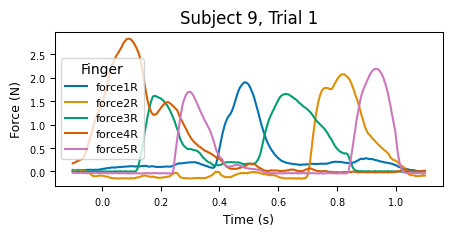

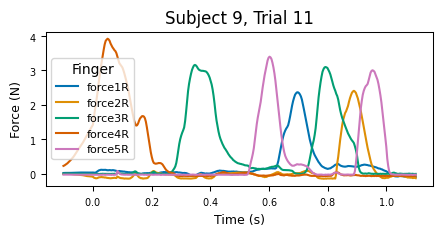

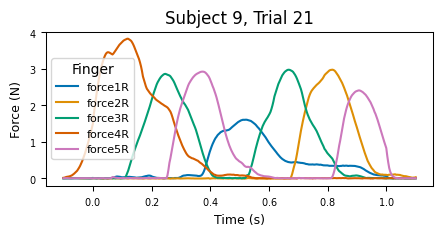

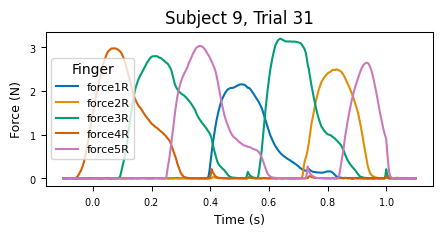

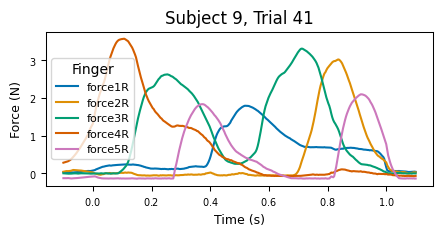

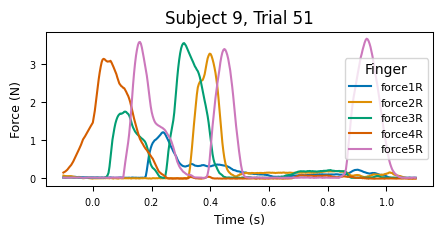

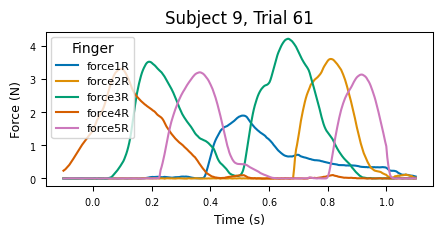

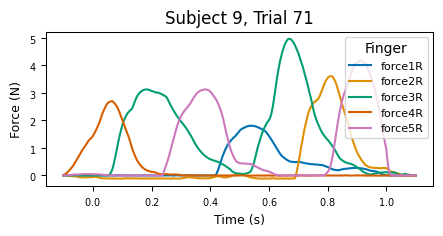

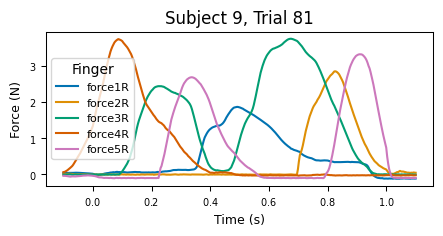

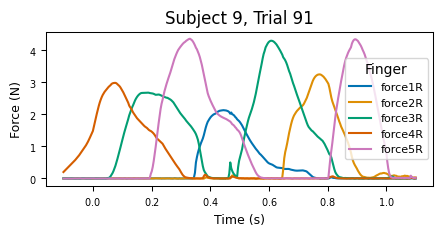

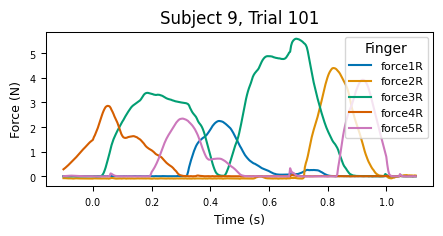

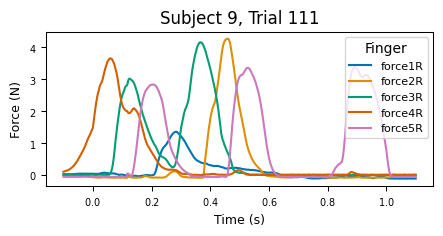

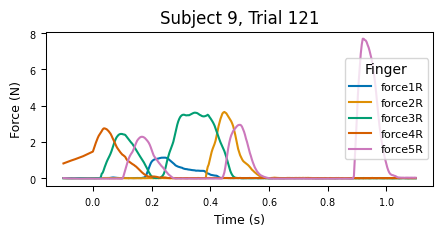

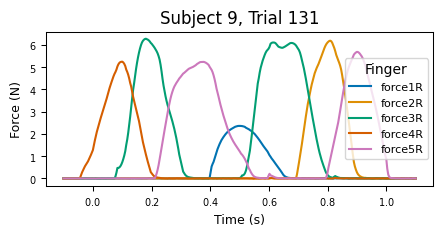

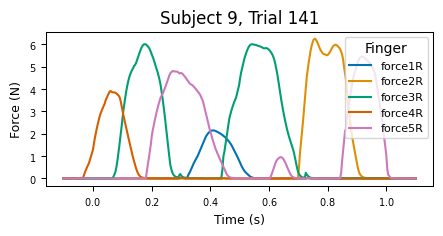

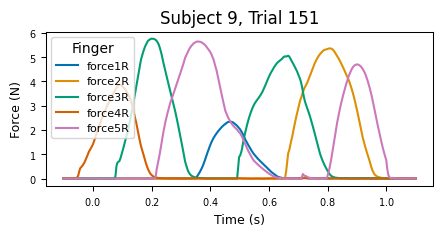

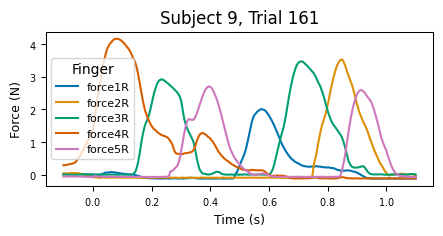

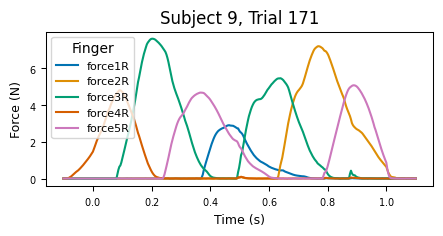

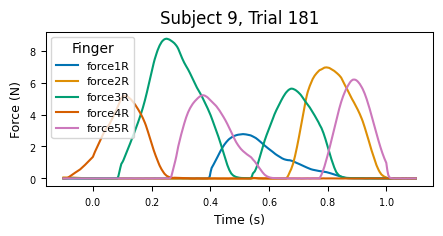

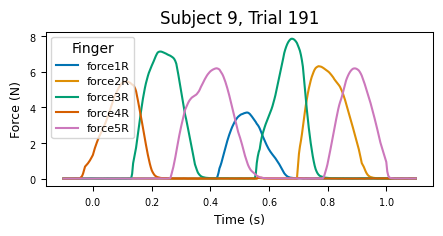

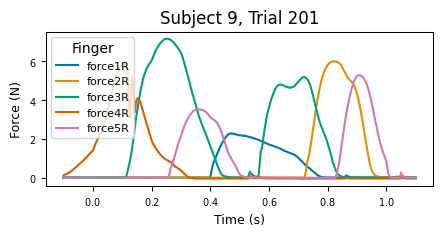

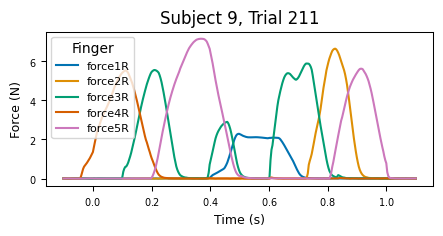

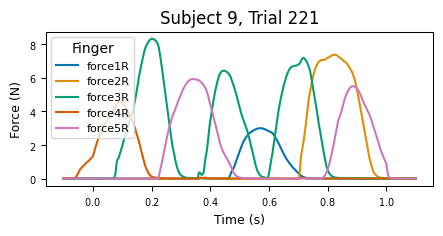

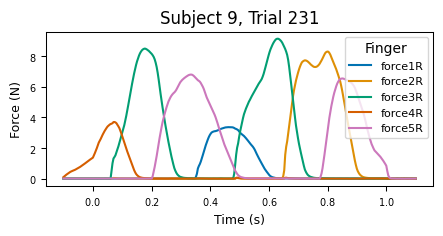

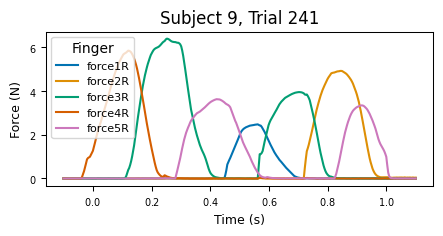

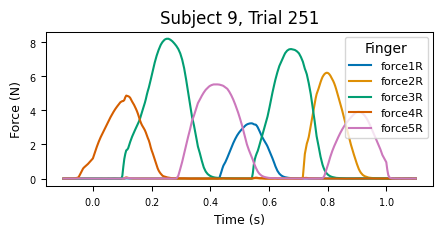

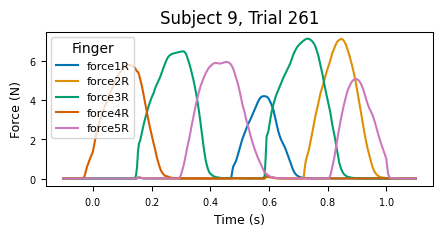

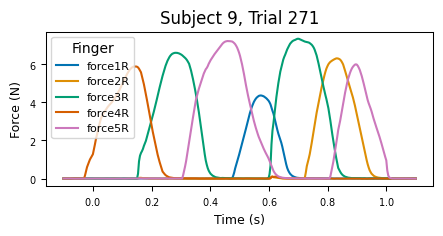

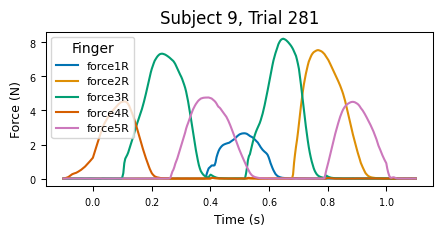

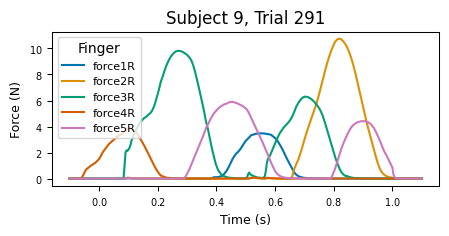

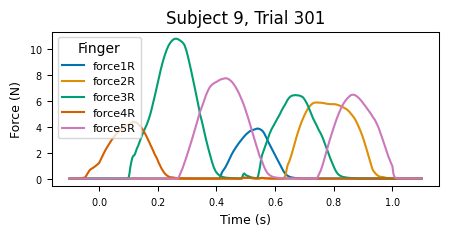

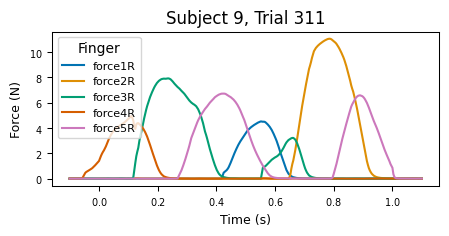

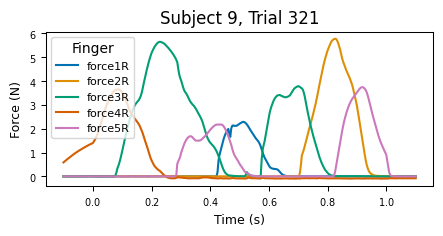

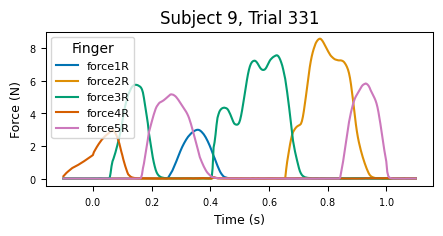

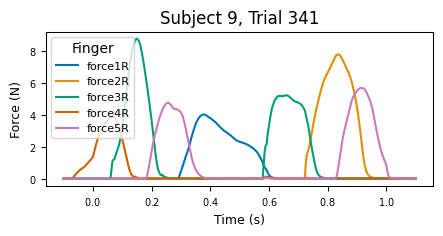

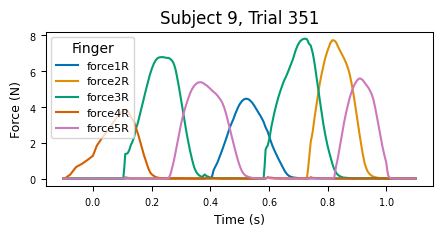

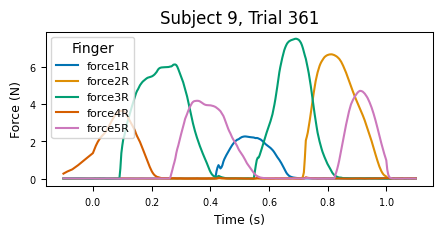

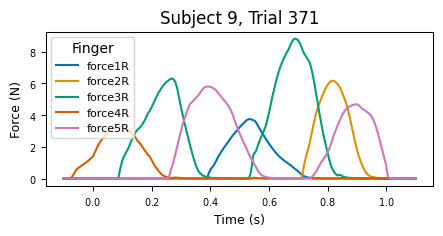

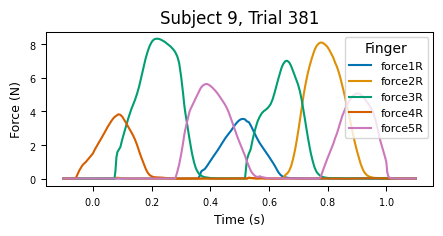

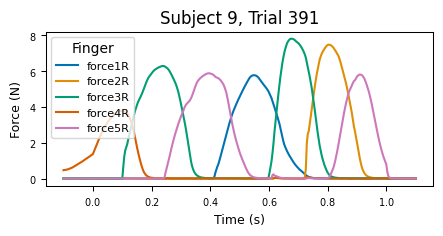

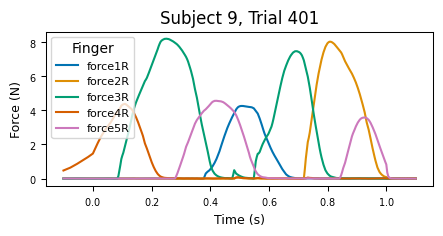

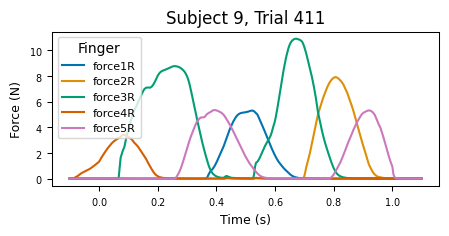

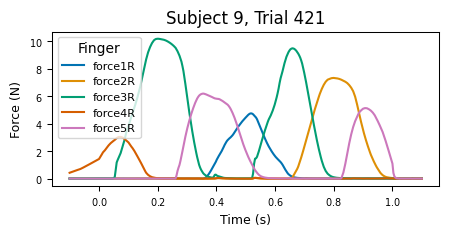

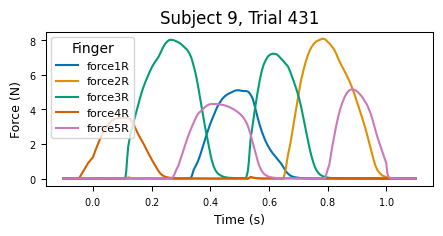

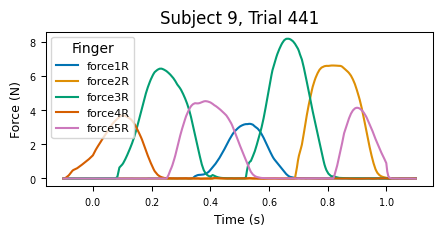

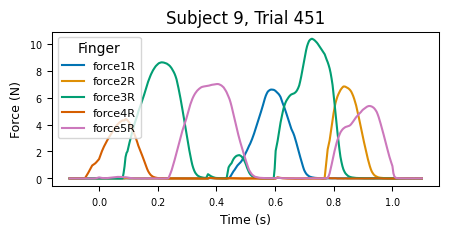

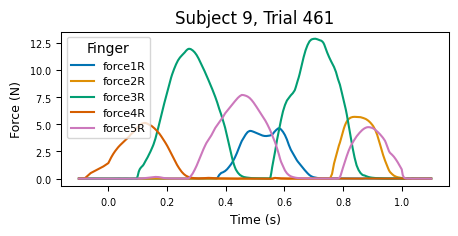

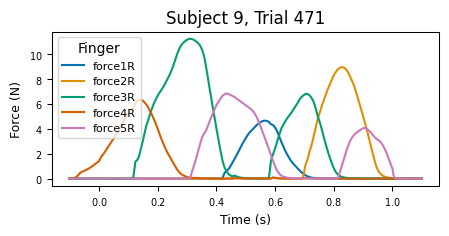

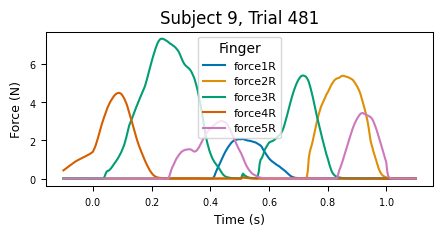

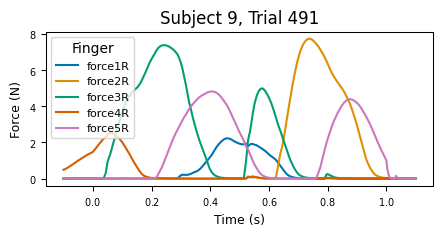

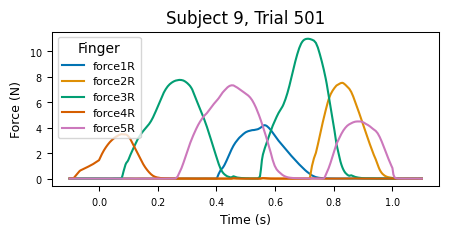

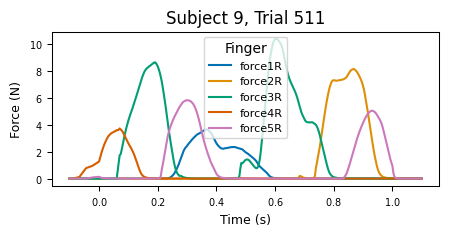

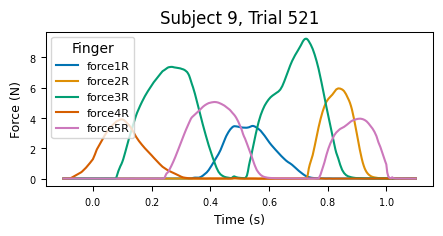

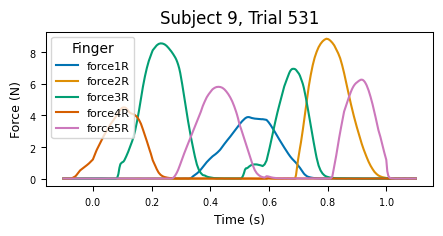

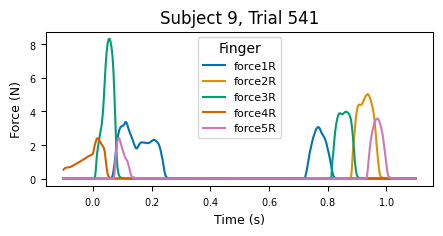

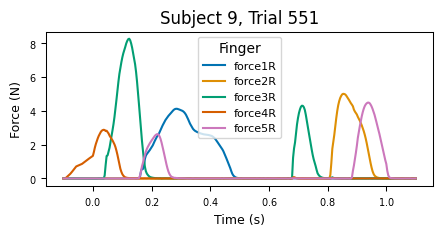

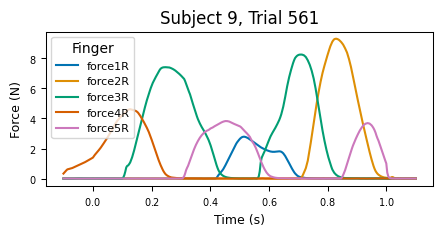

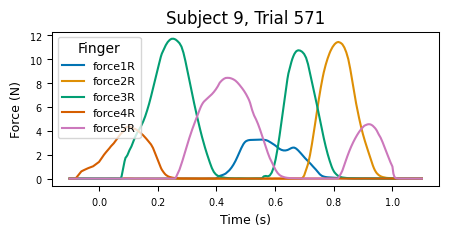

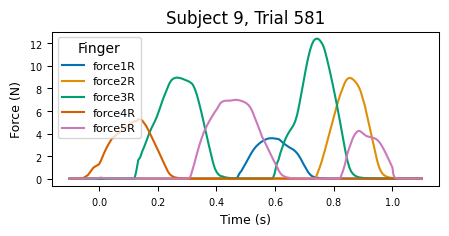

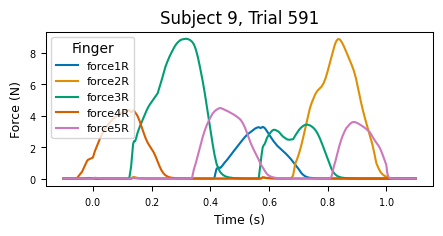

In [262]:
subnum = 9
for i in range(1, 600, 10):
    plot_force(subnum, i)

In [12]:
forces_wide = aligned_cut_force.pivot_table(index=['SubNum', 'BN', 'TN', 'points', 'zone', 'N', 'ET'], columns=['Force_Number', 'time'], values = 'Force_Value').reset_index()
# convert MultiIndex columns to single level
forces_wide.columns = [''.join(map(str, col)).strip() for col in forces_wide.columns.values]
force_cols = [col for col in forces_wide.columns if col.startswith('force')]
new_names = {old: f'force_{i+1}' for i, old in enumerate(force_cols)}
forces_wide.rename(columns=new_names, inplace=True)


In [151]:
# create a force_vector column that is an np array of concatenated forces columns
forces_wide['force_vector'] = forces_wide[[col for col in forces_wide.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)

In [152]:
forces_wide['day'] = 0
forces_wide.loc[forces_wide['BN'].isin(day1_blocks), 'day'] = 1
forces_wide.loc[forces_wide['BN'].isin(day2_blocks), 'day'] = 2
forces_wide.loc[forces_wide['BN'].isin(day3_blocks), 'day'] = 3
forces_wide.loc[forces_wide['BN'].isin(day4_blocks), 'day'] = 4


# adding day change column to the forces_wide dataframe
forces_wide['day_change'] = 0
forces_wide.loc[forces_wide['day'] != forces_wide['day'].shift(1), 'day_change'] = 1

# adding block change column to the forces_wide dataframe
forces_wide['block_change'] = 0
forces_wide.loc[forces_wide['BN'] != forces_wide['BN'].shift(1), 'block_change'] = 1

In [153]:
forces_wide.columns

Index(['SubNum', 'BN', 'TN', 'points', 'zone', 'N', 'ET', 'force_1', 'force_2',
       'force_3',
       ...
       'force_1795', 'force_1796', 'force_1797', 'force_1798', 'force_1799',
       'force_1800', 'force_vector', 'day', 'day_change', 'block_change'],
      dtype='object', length=1811)

# Modulation of Distance based on Reward

In [316]:
# calculate number of points in each zone for each subject
zone_counts = forces_wide.groupby(['SubNum', 'zone', 'points']).size().reset_index(name='count')
zone_counts

,SubNum,zone,points,count
0,1,0,-1,102
1,1,1,3,154
2,1,2,1,73
3,1,2,3,80
4,1,3,0,56
...,...,...,...,...
65,10,2,1,78
66,10,2,3,74
67,10,3,0,75
68,10,3,1,78


In [350]:
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in  subdata.groupby('zone'):
        # loop through all the points in the zonedata
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in the pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty:
                    next_row = next_trial.iloc[0]
                    # compute the euclidean distance between the force vectors of the two trials
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    euclidean_distance = np.linalg.norm(force_vector_1 - force_vector_2)
                    distances.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'distance': euclidean_distance,
                        'BN': row['BN'],
                        'day': row['day'],
                    })
        

distances = pd.DataFrame(distances)
        
distances['count'] = 1

### distribution of distances

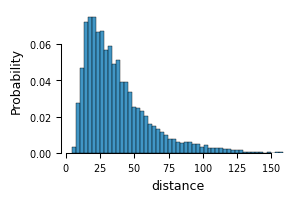

In [351]:
# sns.histplot(data=distances, x='distance', hue='zone', multiple='dodge', stat='probability')
# sns.histplot(data=distances[distances['zone'] == 3], x='distance', hue='zone', multiple='dodge', stat='probability')
sns.histplot(data=distances, x='distance', stat='probability')

sns.despine(trim=True)

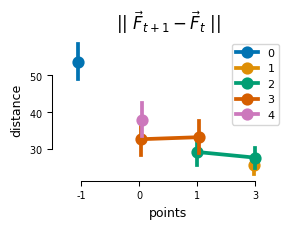

In [352]:
# exclude first three blocks
# distances = distances[distances['BN'] > 3]
grouped_distances = distances.groupby(['SubNum', 'points', 'zone']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_distances = grouped_distances[grouped_distances['zone'].isin([2, 3])]

sns.pointplot(data=grouped_distances, x='points', y='distance', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
plt.legend(loc = 'upper right')
plt.show()

# for group_data in grouped_distances.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['distance'],
#                     group_data[1][group_data[1]['points'] == points[1]]['distance']))

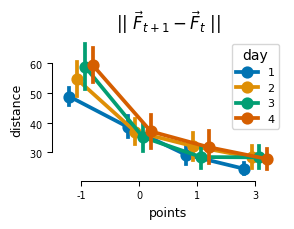

In [356]:
# exclude first three blocks
# distances = distances[distances['BN'] > 3]
# grouped_distances = distances.groupby(['SubNum', 'points', 'day']).agg({'distance': 'median',
#                                                                          'count': 'count'}).reset_index()

grouped_distances = distances.groupby(['SubNum', 'points', 'day']).agg({'distance': 'median',
                                                                         'count': 'count'}).reset_index()


sns.pointplot(data=grouped_distances, x='points', y='distance', hue='day', palette='colorblind', dodge=0.4, errorbar='se')
# sns.pointplot(data=grouped_distances, x='points', y='distance', errorbar='se')

sns.despine(trim=True)
plt.title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
# plt.legend(loc = 'upper right')
plt.show()

# for group_data in grouped_distances.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['distance'],
#                     group_data[1][group_data[1]['points'] == points[1]]['distance']))

# Modulation of cos angel on innovation based on Reward

In [251]:
cosines = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in the pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                prev_trial = subdata[subdata['N'] == N - 1]
                if not next_trial.empty and not prev_trial.empty:
                    next_row = next_trial.iloc[0]
                    prev_row = prev_trial.iloc[0]
                    # compute cosine similarity between difference
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    force_vector_3 = prev_row['force_vector']
                    cosine_similarity = np.dot(force_vector_1 - force_vector_3, force_vector_2 - force_vector_1)/ \
                    (np.linalg.norm(force_vector_1 - force_vector_3) * np.linalg.norm(force_vector_2 - force_vector_1)) 
                    cosines.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'cosine_similarity': cosine_similarity,
                        'BN': row['BN']
                    })


cosines = pd.DataFrame(cosines)
        
cosines['count'] = 1

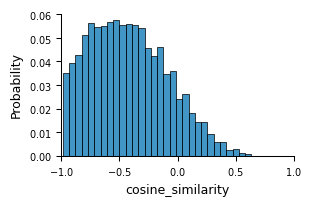

In [252]:
# sns.histplot(data=cosines, x='cosine_similarity', hue='zone', multiple='dodge', stat='probability')
sns.histplot(data=cosines, x='cosine_similarity', multiple='dodge', stat='probability')
plt.xlim(-1, 1)
sns.despine(trim=True)

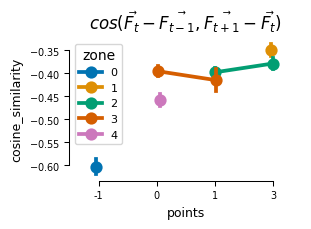

In [253]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'mean',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines =  grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t} - \vec{F_{t-1}}, \vec{F_{t+1}} - \vec{F_t})$')
plt.show()

# for group_data in grouped_cosines.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['cosine_similarity'],
#                     group_data[1][group_data[1]['points'] == points[1]]['cosine_similarity']))



![image.png](attachment:image.png)

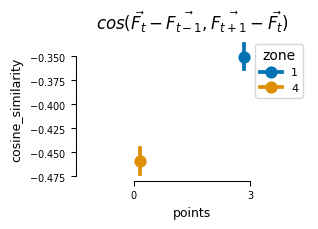

In [166]:
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'mean',
                                                                         'count': 'count'}).reset_index()
grouped_cosines =  grouped_cosines[grouped_cosines['zone'].isin([1, 4])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t} - \vec{F_{t-1}}, \vec{F_{t+1}} - \vec{F_t})$')
plt.show()



# Modulation of cos angel based on Reward

In [342]:
cosines = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty:
                    next_row = next_trial.iloc[0]
                    # compute cosine similarity 
                    force_vector_1 = row['force_vector']
                    force_vector_2 = next_row['force_vector']
                    cosine_similarity = np.dot(force_vector_1, force_vector_2) / \
                    (np.linalg.norm(force_vector_1) * np.linalg.norm(force_vector_2))
                    # append to the cosines list
                    cosines.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'cosine_similarity': cosine_similarity,
                        'BN': row['BN'],
                        'day': row['day']
                    })



cosines = pd.DataFrame(cosines)
        
cosines['count'] = 1

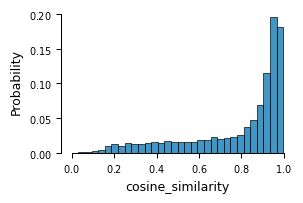

In [343]:
sns.histplot(data=cosines, x='cosine_similarity', stat='probability')
sns.despine(trim=True)

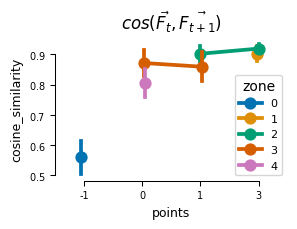

In [344]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'zone']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()

# for group_data in grouped_cosines.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['cosine_similarity'],
#                     group_data[1][group_data[1]['points'] == points[1]]['cosine_similarity']))
    



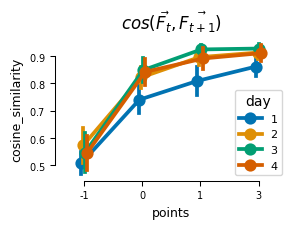

In [349]:
# exclude first three blocks
# cosines = cosines[cosines['BN'] > 3]
grouped_cosines = cosines.groupby(['SubNum', 'points', 'day']).agg({'cosine_similarity': 'median',
                                                                         'count': 'count'}).reset_index()
# grouped_cosines = grouped_cosines[grouped_cosines['zone'].isin([2, 3])]

sns.pointplot(data=grouped_cosines, x='points', y='cosine_similarity', hue='day', palette='colorblind', dodge=0.1, errorbar='se')
sns.despine(trim=True)
plt.title(r'$cos (\vec{F_t}, \vec{F_{t+1}})$')
plt.show()

# for group_data in grouped_cosines.groupby('zone'):
#     points = group_data[1]['points'].unique()
#     print(f"Zone: {group_data[0]}")
#     print(stats.ttest_rel(group_data[1][group_data[1]['points'] == points[0]]['cosine_similarity'],
#                     group_data[1][group_data[1]['points'] == points[1]]['cosine_similarity']))
    



# Modulation of speed based on reward

In [172]:
next_ETs = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for zone, zonedata in subdata.groupby('zone'):
        for point, pointdata in zonedata.groupby('points'):
            # loop through all the points in pointdata
            for i in range(len(pointdata)):
                row = pointdata.iloc[i]
                N = row['N']
                next_trial = subdata[subdata['N'] == N + 1]
                if not next_trial.empty:
                    next_row = next_trial.iloc[0]
                    # append to the next_ETs list
                    next_ETs.append({
                        'SubNum': subind,
                        'points': point,
                        'zone': row['zone'],
                        'ET':  next_row['ET'],
                        'BN': row['BN']
                    })


        

next_ETs = pd.DataFrame(next_ETs)
        
next_ETs['count'] = 1

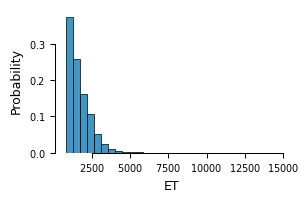

In [173]:
sns.histplot(data = next_ETs, x='ET', stat='probability', bins=30)
sns.despine(trim=True)

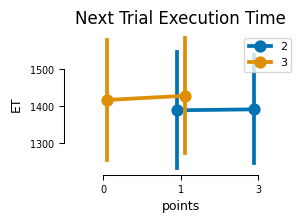

In [174]:
# next_ETs = next_ETs[next_ETs['BN'] > 3]  # Exclude first three block
grouped_speeds = next_ETs.groupby(['SubNum', 'zone', 'points']).agg({'ET': 'median'}).reset_index()

grouped_speeds = grouped_speeds[grouped_speeds['zone'].isin([2, 3])]
sns.pointplot(data=grouped_speeds, x='points', y='ET', hue='zone', palette='colorblind', dodge=0.1, errorbar='se')
plt.title('Next Trial Execution Time')
plt.legend(loc='upper right')

sns.despine(trim=True)


# Modulation of Variance over Learning

In [365]:
# calculate variance of forces on a moving window for each subject
window_size = 10
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]
        # window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))
        # compute the variance of the force vectors in the window
        force_vectors = np.array(window_data['force_vector'].tolist())
        mean_force = np.mean(force_vectors, axis=0)
        var = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis = 1).mean())
        # var = stats.iqr(((force_vectors - mean_force) ** 2).sum(axis = 1))

        distances.append({
            'SubNum': subind,
            'variance': var,
            'N': window_data['N'].values[0]
        })

distances = pd.DataFrame(distances)

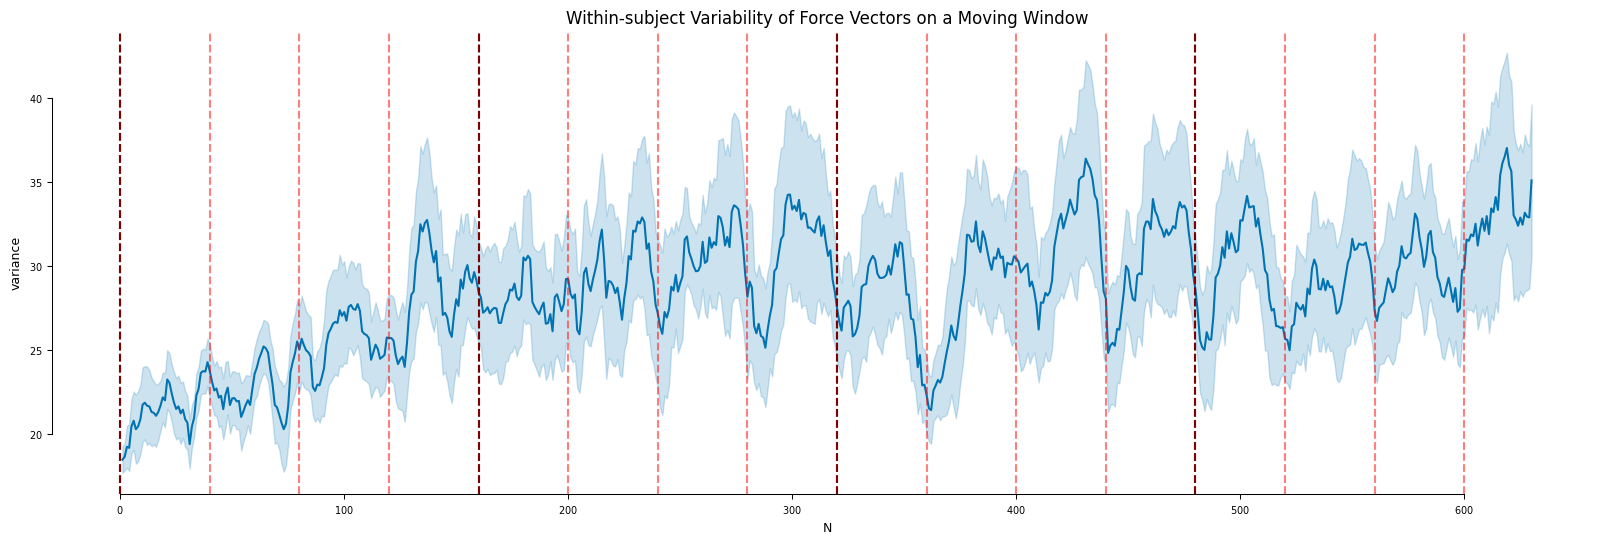

In [366]:
plt.figure(figsize=(20, 6))
# distances = distances[distances['SubNum'] == 10]
# distances = distances[~distances['SubNum'].isin([1,2])]
sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Within-subject Variability of Force Vectors on a Moving Window')

sns.despine(trim=True)

In [301]:
# calculate variance of forces on a moving window for each subject
window_size = 10
distances = []


for N, ndata in forces_wide.groupby('N'):
    force_vectors = np.array(ndata['force_vector'].tolist())
    mean_force = np.mean(force_vectors, axis=0)
    var = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis = 1).mean())

    distances.append({
        'variance': var,
        'N': N
    })

distances = pd.DataFrame(distances)

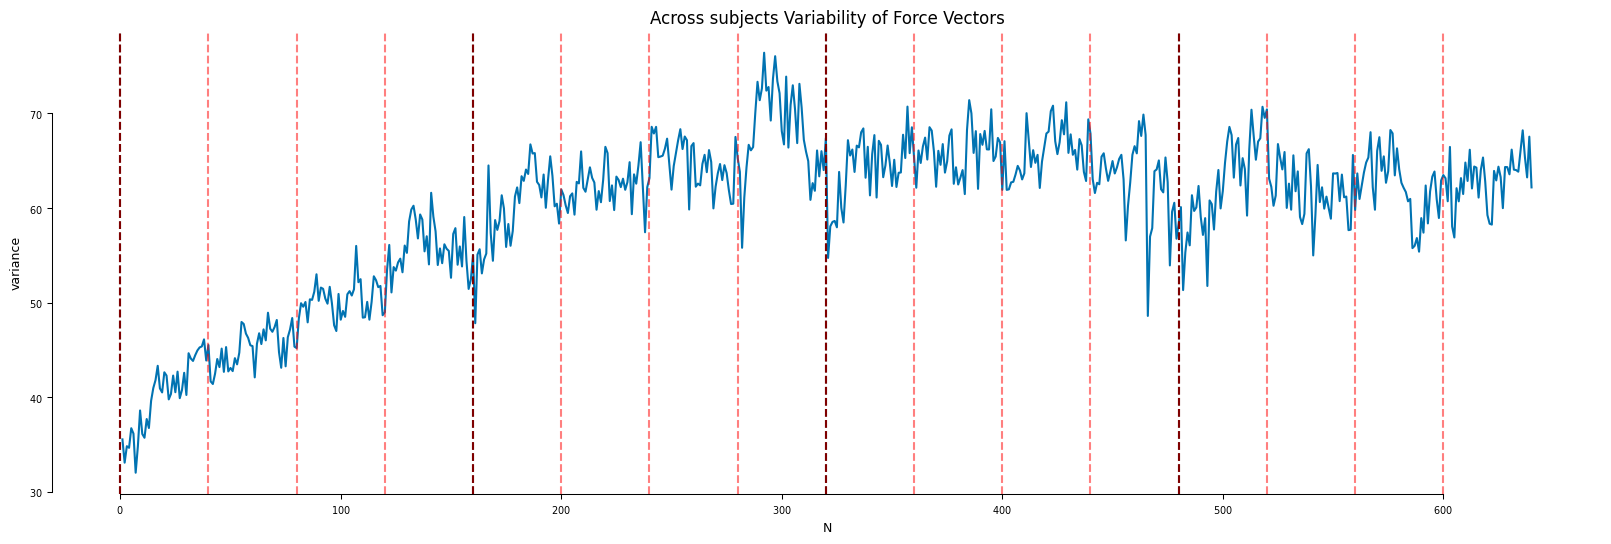

In [302]:
plt.figure(figsize=(20, 6))

sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)

# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)
    
plt.title('Across subjects Variability of Force Vectors')
sns.despine(trim=True)


In [373]:
# calculate variance of ETs on a moving window for each subject
window_size = 10
distances = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]

        # window_data = window_data[window_data['points'] != -1]


        # compute iqr of the ETs in the window
        # var = stats.iqr(window_data['ET'].values)

        # compute the variance of the ETs in the window
        var = np.std(window_data['ET'].values)

        distances.append({
            'SubNum': subind,
            'variance': var,
            'N': window_data['N'].values[0]
        })

distances = pd.DataFrame(distances)

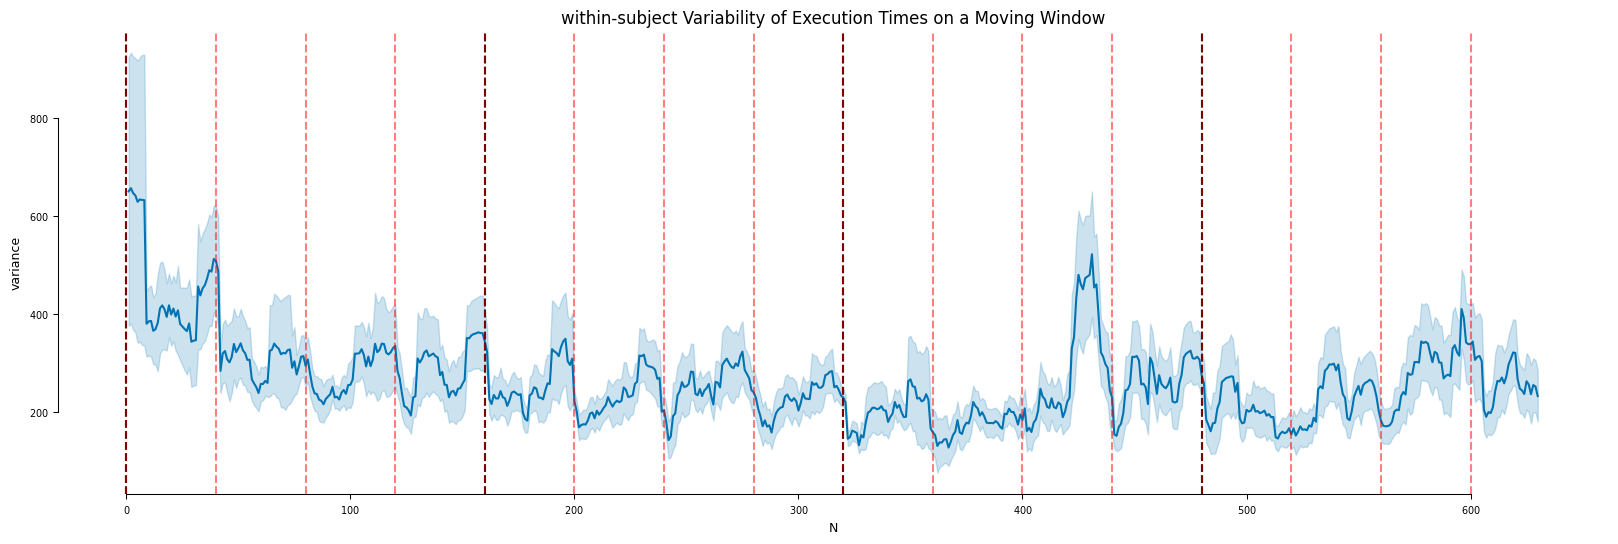

In [374]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)


plt.title('within-subject Variability of Execution Times on a Moving Window')
sns.despine(trim=True)

In [303]:
# calculate variance of ETs on a moving window for each subject
window_size = 10
distances = []


for N, ndata in forces_wide.groupby('N'):
    var = np.std(ndata['ET'].values)

    distances.append({
        'variance': var,
        'N': N
    })

distances = pd.DataFrame(distances)

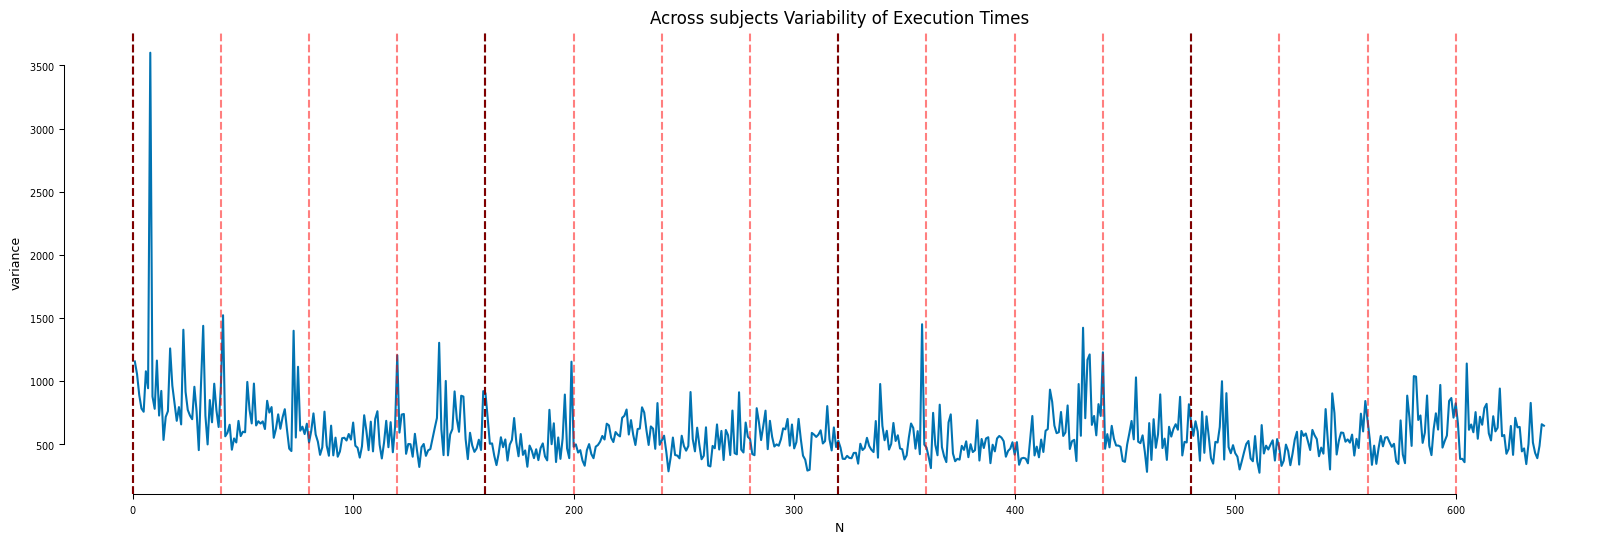

In [304]:
plt.figure(figsize=(20, 6))

sns.lineplot(data=distances, x='N', y='variance', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)

# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)
    
plt.title('Across subjects Variability of Execution Times')
sns.despine(trim=True)


In [306]:
# calculate mean of ETs on a moving window for each subject
window_size = 20
means = []
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(len(subdata) - window_size):
        window_data = subdata.iloc[i:i + window_size]
        # compute the variance of the ETs in the window
        mean = np.mean(window_data['ET'].values)
        mean = np.median(window_data['ET'].values)  # Use median to reduce the effect of outliers

        means.append({
            'SubNum': subind,
            'mean': mean,
            'N': window_data['N'].values[0]
        })

means = pd.DataFrame(means)

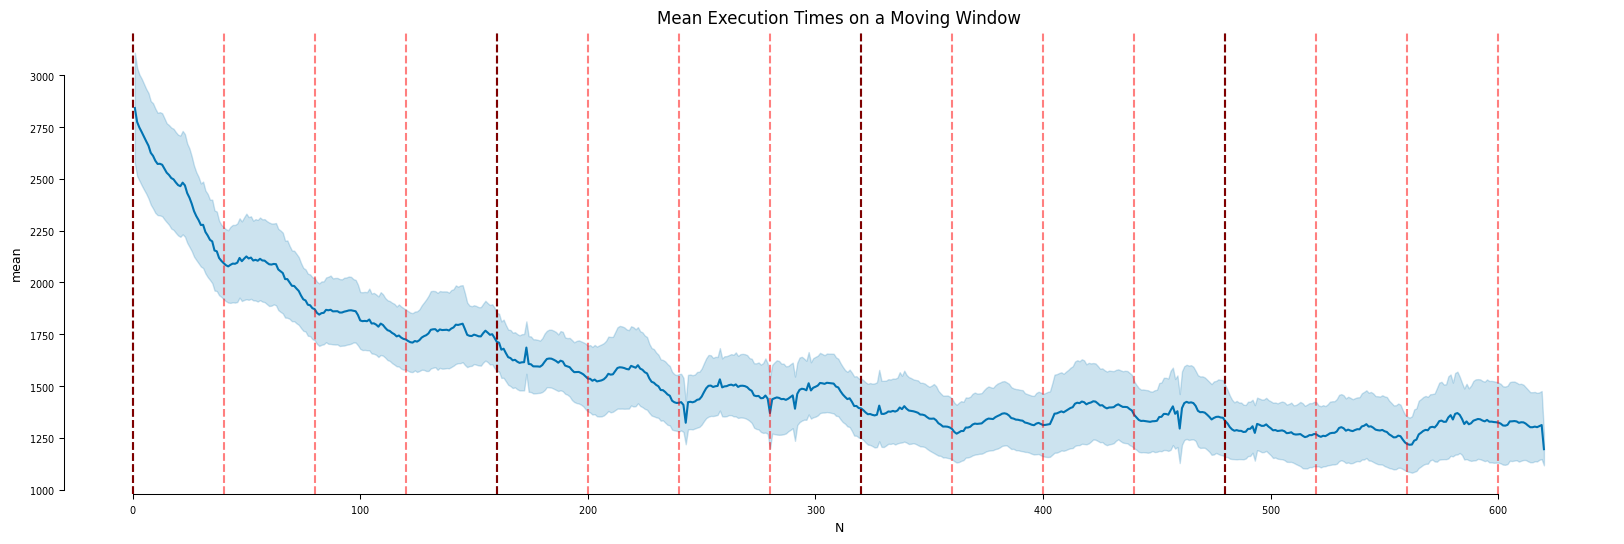

In [307]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=means, x='N', y='mean', errorbar='se')

#plot day changes
day_changes = forces_wide[forces_wide['day_change'] == 1]
for n in day_changes['N'].unique():
    plt.axvline(n - 1, color='black', linestyle='--', alpha=1)


# plot block changes
block_changes = forces_wide[forces_wide['block_change'] == 1]
for n in block_changes['N'].unique():
    plt.axvline(n - 1, color='red', linestyle='--', alpha=0.5)


plt.title('Mean Execution Times on a Moving Window')
sns.despine(trim=True)

In [384]:
window_size = 50
force_ET_trend = []

for subind, subdata in forces_wide.groupby('SubNum'):
    # bin the data into windows of size window_size
    for i in range(0, len(subdata) - window_size + 1, window_size):
        # print(i, i + window_size)

        window_data = subdata.iloc[i:i + window_size]

        # window_data = window_data[window_data['points'] != -1]
        # print(len(window_data))

        force_vectors = np.array(window_data['force_vector'].tolist())
        # compute the mean of the force vectors in the window
        mean_force_vector = np.mean(force_vectors, axis=0)
        # compute the variance of the force vectors in the window
        var = np.sqrt(((force_vectors - mean_force_vector) ** 2).sum(axis = 1).mean())


        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'variance': var,
            'mean_ET': mean_ET,
            'bin': i // window_size + 1
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


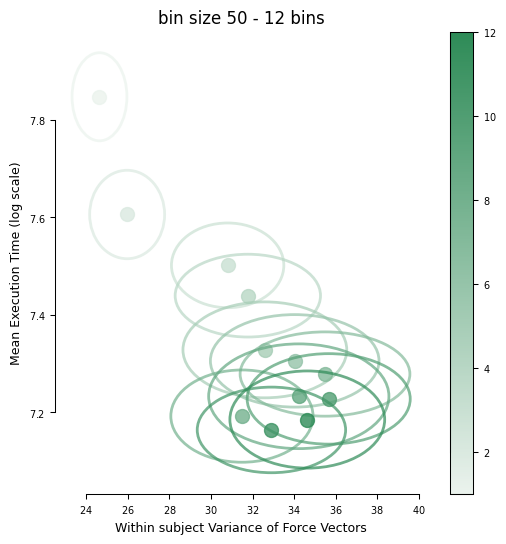

In [385]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()

for i, (binnum, bin_data) in enumerate(force_ET_trend.groupby('bin')):
    mean_x = bin_data['variance'].mean()
    mean_y = np.log(bin_data['mean_ET']).mean()
    se_x = bin_data['variance'].std() / np.sqrt(len(bin_data))
    se_y = np.log(bin_data['mean_ET']).std() / np.sqrt(len(bin_data))

   # Plot the mean point
    ax.scatter(mean_x, mean_y, c=binnum, s=100, label=f'Bin {binnum}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    
    # Draw the SE ellipse
    ellipse = Ellipse(
        (mean_x, mean_y),
        width=2*se_x,  # ±1 SE
        height=2*se_y,
        edgecolor=cmap(norm(binnum)),
        facecolor='none',
        lw=2,
        alpha=0.7
    )
    ax.add_patch(ellipse)


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)


plt.xlabel('Within subject Variance of Force Vectors')
plt.ylabel('Mean Execution Time (log scale)')
plt.title(f"bin size {window_size} - {n_bins} bins")
# plt.legend(title='Bin', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True)

    

In [386]:
window_size = 50
force_ET_trend = []

# bin the data into windows of size window_size
for subind, subdata in forces_wide.groupby('SubNum'):
    for i in range(0, len(subdata) - window_size + 1, window_size):
        # print(i, i + window_size)
        window_data = subdata.iloc[i:i + window_size]
        force_vectors = np.array(window_data['force_vector'].tolist())
        # compute the mean of the force vectors in the window
        mean_force_vector = np.mean(force_vectors, axis=0)
        # compute the mean ET in the window
        mean_ET = np.mean(window_data['ET'].values)
        
        force_ET_trend.append({
            'SubNum': subind,
            'mean_force': mean_force_vector,
            'mean_ET': mean_ET,
            'bin': i // window_size + 1
        })

force_ET_trend = pd.DataFrame(force_ET_trend)


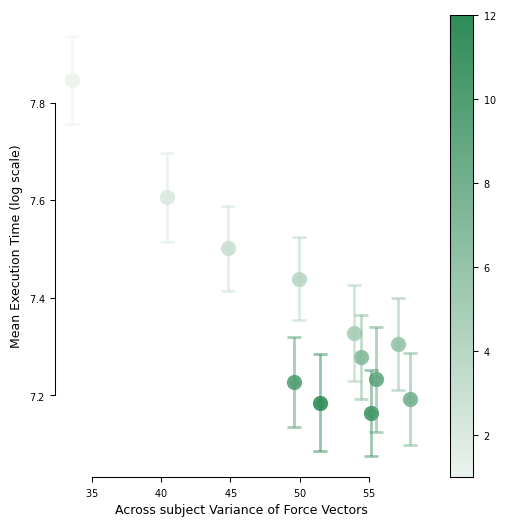

In [387]:
plt.figure(figsize=(6, 6))
n_bins = force_ET_trend['bin'].nunique()
norm = plt.Normalize(vmin=force_ET_trend['bin'].min(), vmax=force_ET_trend['bin'].max())
cmap = sns.light_palette("seagreen", as_cmap=True, n_colors = n_bins)
ax = plt.gca()
for bin, bindata in force_ET_trend.groupby('bin'):
    force_vectors = np.array(bindata['mean_force'].tolist())
    mean_force = bindata['mean_force'].mean()
    mean_y = np.log(bindata['mean_ET']).mean()

    variation_force = np.sqrt(((force_vectors - mean_force) ** 2).sum(axis=1).mean())
    se_y = np.log(bindata['mean_ET']).std() / np.sqrt(len(bindata))

    # Plot the mean point
    ax.scatter(variation_force, mean_y, c=bin, s=100, label=f'Bin {bin}', alpha=0.8, cmap = cmap,
               norm = norm)
    
    # sns.scatterplot(x=[variation_force], y=[mean_y], color=cmap(norm(bin)), s=100, edgecolor='black', alpha=0.8,
    #                 )

    # add error bars
    ax.errorbar(variation_force, mean_y, yerr=se_y, fmt='o', color=cmap(norm(bin)), alpha=0.5,
                capsize=5, elinewidth=2, markeredgewidth=2)
    


cbar = plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
plt.xlabel('Across subject Variance of Force Vectors')
plt.ylabel('Mean Execution Time (log scale)')

sns.despine(trim=True)
    

    